<a href="https://colab.research.google.com/github/rosafilgueira/Workflows_Seminar/blob/main/Monitoring_Traces_dispel4py_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# dispel4py With Monitoring Traces

`dispel4py` is a free and open-source Python library for describing abstract stream-based workflows for distributed data-intensive applications. It enables users to focus on scientific methods while keeping flexibility across infrastructures. The same workflow can be executed on multiple mappings (sequential, multiprocessing, MPI), without changing workflow logic.

## Python Version

This version has been tested with Python `3.10`.  
For older Python-compatible versions (`<3.10`), please refer to earlier releases.

## What We Added in This Notebook

In this notebook, we added **monitoring-enabled mappings**:

- `timed_simple`
- `timed_multi`
- `timed_mpi`

These mappings execute workflows as usual, but also collect:

- per-PE and per-PE-instance timing summaries
- per-iteration latency traces
- latency statistics (`min`, `p50`, `p95`, `max`)
- abstract workflow graph shape
- concrete runtime (instance/rank) graph shape
- optional graph figures (`.png`)

## Execution Strategy Used Here

We run workflows in two modes:

1. **Baseline run (no monitoring)** using standard mapping (`simple`, `multi`, or `mpi`)
2. **Monitoring run** using timed mapping (`timed_simple`, `timed_multi`, or `timed_mpi`)

Exception:

- The last two workflows (`parallel_pipeline` and `split_merge`) are run **only with monitoring**.

## Output Location Convention

All monitoring artifacts are written to:

`/content/results/<WORKFLOW_TRACES>`

Example:

```bash
--timing-dir /content/results/WORD_COUNT_TRACES
```

## Timed Mapping Commands

### `timed_simple` (sequential)

```bash
dispel4py timed_simple <workflow_module> -i <iterations> --timing-dir /content/results/<WORKFLOW_TRACES>
```

### `timed_multi` (multiprocessing, shared memory)

```bash
dispel4py timed_multi <workflow_module> -i <iterations> -n <num_processes> --timing-dir /content/results/<WORKFLOW_TRACES>
```

### `timed_mpi` (distributed memory)

```bash
mpiexec -n <num_ranks> dispel4py timed_mpi <workflow_module> -i <iterations> -n <num_ranks> --timing-dir /content/results/<WORKFLOW_TRACES>
```

## Monitoring Flags

Common flags for all timed mappings:

- `--timing-dir`: output folder path
- `--timing-prefix`: output filename prefix (default: `monitor`)
- `--run-id`: custom run identifier
- `--print-shape`: print abstract and concrete graph shape
- `--no-graph-figures`: disable `.png` graph generation

Optional output-file override flags:

- `--summary-file`
- `--instance-summary-file`
- `--iteration-summary-file`
- `--iteration-latency-summary-file`
- `--shape-file`
- `--concrete-shape-file`
- `--abstract-figure-file`
- `--concrete-figure-file`

## Monitoring Output Files (What They Mean)

- `monitor_shape_run<id>.json`  
  Abstract workflow graph (as defined by user).

- `monitor_concrete_shape_run<id>.json`  
  Concrete runtime graph (PE instances/ranks and edges).

- `monitor_summary_run<id>.csv`  
  Per-PE summary across all ranks (`total`, `avg`, `min`, `p50`, `p95`, `max`).

- `monitor_instances_run<id>.csv`  
  Per-instance (`PE@rank`) summary with latency stats.

- `monitor_iteration_timings_run<id>.csv`  
  Merged per-iteration timing rows across all instances.

- `monitor_iteration_timings_summary_run<id>.csv`  
  Per-instance latency summary derived from per-iteration timings.

- `monitor_<PE>_rank<R>_run<id>.csv`  
  Raw per-instance total summary file.

- `monitor_iterations_<PE>_rank<R>_run<id>.csv`  
  Raw per-iteration file for one PE instance.

- `monitor_abstract_graph_run<id>.png`  
  Figure of abstract graph.

- `monitor_concrete_graph_run<id>.png`  
  Figure of concrete runtime graph.

## Latency Metrics Quick Guide

- `p50_secs`: median latency (50th percentile)
- `p95_secs`: tail latency (95th percentile)
- `max_secs`: slowest observed latency

If `p95_secs` is much higher than `p50_secs`, execution has high variability/tail effects.


#Dispel4py instatllation

Note that the all the monitoring work **is not currently captured** in `stream-d4py` pip package. So, we need to install `dispel4py` by cloning the repository and type `python setup.py install`, as we have it here in the following cell:

In [ ]:

!git clone https://github.com/StreamingFlow/d4py.git
%cd d4py
%pip install mpi4py
!python setup.py install

Cloning into 'd4py'...
remote: Enumerating objects: 443, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 443 (delta 64), reused 93 (delta 37), pack-reused 318 (from 1)
Receiving objects: 100% (443/443), 15.58 MiB | 7.88 MiB/s, done.
Resolving deltas: 100% (193/193), done.
/content/d4py
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.4 MB/s eta 0:00:00
installing dispel4py
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        **************************************************************

## Part I- Simple Examples

This [directory](https://github.com/StreamingFlow/d4py/tree/main/dispel4py/examples/graph_testing) contains a collection of dispel4py workflows used for testing and validating the functionalities and behavior of dataflow graphs. These workflows are primarily used for testing purposes and ensure that the different mappings (e.g., simple, MPI, Storm) and various features of dispel4py work as expected. They help in verifying the correctness and efficiency of dataflow graphs during development and maintenance of the dispel4py library

Those examples are available in the installed version of dispel4py. To use them, you just need to indicate `dispel4py.examples.graph_testing.<WORKFLOW>` in the command line when using dispel4py.

### Word_Count dispel4py Workflow

We are going to use the word_count.py dispel4py workflow. This workflow counts words produced by a WordProducer.

```

from dispel4py.examples.graph_testing.testing_PEs import RandomWordProducer, WordCounter
from dispel4py.workflow_graph import WorkflowGraph

words = RandomWordProducer()
words.numprocesses = 1
counter = WordCounter()
counter.numprocesses = 3
graph = WorkflowGraph()
graph.connect(words, "output", counter, "input")
```

In this initial exploration of dispel4oy we are going to test three "mappings" - execution strategies that dispel4py employs to adapt workflows for different computing environments, ranging from sequential processing on a single core to distributed computing across multiple nodes, demonstrating dispel4py's flexibility and scalability. Here we are going to test two mappings:
  * simple: sequential execution
  * multi: parallel (shared memory) execution
  * mpi: parallel (distributed memory) execution

In [ ]:
## Simple mapping (no monitoring)
!dispel4py simple dispel4py.examples.graph_testing.word_count -i 10

Processing 10 iterations.
RUN ARGS: 
Namespace(target='simple', module='dispel4py.examples.graph_testing.word_count', attr=None, file=None, data=None, iter=10, provenance=None)
Inputs: {'RandomWordProducer0': 10}
SimplePE: Processed 1 iteration.
Outputs: {'WordCounter1': {'output': [[np.str_('Dispel4Py'), 1], [np.str_('Computing'), 1], [np.str_('Modelling'), 1], [np.str_('Analysis'), 1], [np.str_('Infrastructure'), 1], [np.str_('Dispel4Py'), 2], [np.str_('Infrastructure'), 2], [np.str_('Seismology'), 1], [np.str_('Computing'), 2], [np.str_('Earthquake'), 1]]}}
ELAPSED TIME: 0.0030782222747802734


In [ ]:
## Simple mapping - WITH monitoring
!dispel4py timed_simple dispel4py.examples.graph_testing.word_count -i 10 --timing-dir /content/results/word_count_simple

Processing 10 iterations.
RUN ARGS: 
Namespace(target='timed_simple', module='dispel4py.examples.graph_testing.word_count', attr=None, file=None, data=None, iter=10, provenance=None, timing_dir='/content/results/word_count_simple', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summary_file=None, iteration_latency_summary_file=None, shape_file=None, concrete_shape_file=None, abstract_figure_file=None, concrete_figure_file=None, no_graph_figures=False, print_shape=False)
Timing monitor enabled for 2 PEs (run_id=20260424T180836340452Z).
Inputs: {'RandomWordProducer0': 10}
RandomWordProducer0 (rank 0): Average processing time: 5.059242248535156e-05
WordCounter1 (rank 1): Average processing time: 2.6941299438476564e-06
SimplePE: Processed 1 iteration.
Outputs: {'WordCounter1': {'output': [[np.str_('Computing'), 1], [np.str_('Dispel4Py'), 1], [np.str_('Modelling'), 1], [np.str_('Infrastructure'), 1], [np.str_('Infrastructure'), 2], [np.

Note that when executing in a parallel environment the output from each PE is not collected as in the simple mapping.

You are responsible for collecting this output and printing or storing it. Threfore, in this case, we wont see anything in the `Outputs`, when running with MULTI and MPI mappings.

In [ ]:
## Multi mapping (no monitoring)
!python -m dispel4py.new.processor multi dispel4py.examples.graph_testing.word_count -i 10 -n 4


Processing 10 iterations.
RUN ARGS: 
Namespace(target='multi', module='dispel4py.examples.graph_testing.word_count', attr=None, file=None, data=None, iter=10, provenance=None, simple=False, num=4)
Processes: {'RandomWordProducer0': range(0, 1), 'WordCounter1': range(1, 4)}
RandomWordProducer0 (rank 0): Processed 10 iterations.
WordCounter1 (rank 1): Processed 6 iterations.
WordCounter1 (rank 2): Processed 1 iteration.
WordCounter1 (rank 3): Processed 3 iterations.
ELAPSED TIME: 0.047292232513427734


In [ ]:
## Multi mapping - with  monitoring
!dispel4py timed_multi dispel4py.examples.graph_testing.word_count -i 10 -n 4 --timing-dir /content/results/word_count_multi_n4

Processing 10 iterations.
RUN ARGS: 
Namespace(target='timed_multi', module='dispel4py.examples.graph_testing.word_count', attr=None, file=None, data=None, iter=10, provenance=None, simple=False, num=4, timing_dir='/content/results/word_count_multi_n4', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summary_file=None, iteration_latency_summary_file=None, shape_file=None, concrete_shape_file=None, abstract_figure_file=None, concrete_figure_file=None, no_graph_figures=False, print_shape=False)
Timing monitor enabled for 2 PEs (run_id=20260424T180842137690Z).
Processes: {'RandomWordProducer0': range(0, 1), 'WordCounter1': range(1, 4)}
RandomWordProducer0 (rank 0): Average processing time: 0.0002914905548095703
RandomWordProducer0 (rank 0): Processed 10 iterations.
WordCounter1 (rank 1): Average processing time: 1.5497207641601562e-05
WordCounter1 (rank 1): Processed 4 iterations.
WordCounter1 (rank 2): Average processing time: 0.0
Wor

In [ ]:
## MPI mapping (no monitoring)
!mpiexec -n 4 --allow-run-as-root --oversubscribe  dispel4py mpi dispel4py.examples.graph_testing.word_count -n 4

Processing 1 iteration.
Processing 1 iteration.
Processing 1 iteration.
Processing 1 iteration.
RUN ARGS: 
Namespace(target='mpi', module='dispel4py.examples.graph_testing.word_count', attr=None, file=None, data=None, iter=1, provenance=None, simple=False, num_processes=4)
RUN ARGS: 
RUN ARGS: 
RUN ARGS: 
Namespace(target='mpi', module='dispel4py.examples.graph_testing.word_count', attr=None, file=None, data=None, iter=1, provenance=None, simple=False, num_processes=4)
Processes: {'RandomWordProducer0': range(0, 1), 'WordCounter1': range(1, 4)}
Namespace(target='mpi', module='dispel4py.examples.graph_testing.word_count', attr=None, file=None, data=None, iter=1, provenance=None, simple=False, num_processes=4)
Namespace(target='mpi', module='dispel4py.examples.graph_testing.word_count', attr=None, file=None, data=None, iter=1, provenance=None, simple=False, num_processes=4)
RandomWordProducer0 (rank 0): Processed 1 iteration.
WordCounter1 (rank 1): Processed 0 iterations.
WordCounter1 (r

In [ ]:
## MPI mapping - with  monitoring
!mpiexec -n 4 --allow-run-as-root --oversubscribe dispel4py timed_mpi dispel4py.examples.graph_testing.word_count -i 10 -n 4 --timing-dir /content/results/word_count_mpi_n4


Processing 10 iterations.
Processing 10 iterations.
Processing 10 iterations.
Processing 10 iterations.
RUN ARGS: 
RUN ARGS: 
RUN ARGS: 
RUN ARGS: 
Namespace(target='timed_mpi', module='dispel4py.examples.graph_testing.word_count', attr=None, file=None, data=None, iter=10, provenance=None, simple=False, num_processes=4, timing_dir='/content/results/word_count_mpi_n4', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summary_file=None, iteration_latency_summary_file=None, shape_file=None, concrete_shape_file=None, abstract_figure_file=None, concrete_figure_file=None, no_graph_figures=False, print_shape=False)
Namespace(target='timed_mpi', module='dispel4py.examples.graph_testing.word_count', attr=None, file=None, data=None, iter=10, provenance=None, simple=False, num_processes=4, timing_dir='/content/results/word_count_mpi_n4', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summar

In [ ]:
## MPI mapping (no monitoring)
!mpiexec -n 10 --allow-run-as-root --oversubscribe  dispel4py mpi dispel4py.examples.graph_testing.pipeline_test -i 20 -n 10

Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
RUN ARGS: 
Namespace(target='mpi', module='dispel4py.examples.graph_testing.pipeline_test', attr=None, file=None, data=None, iter=20, provenance=None, simple=False, num_processes=10)
RUN ARGS: 
Namespace(target='mpi', module='dispel4py.examples.graph_testing.pipeline_test', attr=None, file=None, data=None, iter=20, provenance=None, simple=False, num_processes=10)
RUN ARGS: 
Namespace(target='mpi', module='dispel4py.examples.graph_testing.pipeline_test', attr=None, file=None, data=None, iter=20, provenance=None, simple=False, num_processes=10)
RUN ARGS: 
Namespace(target='mpi', module='dispel4py.examples.graph_testing.pipeline_test', attr=None, file=None, data=None, iter=20, provenance=None, simple=False, num_processes=10)
RUN ARGS

In [ ]:
## MPI mapping - with monitoring
!mpiexec -n 10 --allow-run-as-root --oversubscribe  dispel4py timed_mpi dispel4py.examples.graph_testing.pipeline_test -i 20 -n 10 --timing-dir /content/results/word_count_mpi_n10

Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
Processing 20 iterations.
RUN ARGS: 
Namespace(target='timed_mpi', module='dispel4py.examples.graph_testing.pipeline_test', attr=None, file=None, data=None, iter=20, provenance=None, simple=False, num_processes=10, timing_dir='/content/results/word_count_mpi_n10', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summary_file=None, iteration_latency_summary_file=None, shape_file=None, concrete_shape_file=None, abstract_figure_file=None, concrete_figure_file=None, no_graph_figures=False, print_shape=False)
RUN ARGS: 
Namespace(target='timed_mpi', module='dispel4py.examples.graph_testing.pipeline_test', attr=None, file=None, data=None, iter=20, provenance=None, simple=False, num_processes=10, timing_dir='/c

## Part II - Real Use Cases

This [repository](https://github.com/StreamingFlow/d4py_workflows.git) contains more complex "real-world" examples for specific scientific domains.

We are going to clone it! And lets use the ones that are under "Others" directory

In [ ]:
!pwd

/content/d4py


In [ ]:
!git clone https://github.com/StreamingFlow/d4py_workflows.git

Cloning into 'd4py_workflows'...
remote: Enumerating objects: 748, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 748 (delta 52), reused 68 (delta 28), pack-reused 649 (from 1)
Receiving objects: 100% (748/748), 14.06 MiB | 5.65 MiB/s, done.
Resolving deltas: 100% (356/356), done.


### Covid Workflow

[covid_workflow](./https://github.com/StreamingFlow/d4py_workflows/blob/main/others/covid_workflow.py) is focused on fetching, processing, and visualizing COVID-19 data, specifically for India. It begins with a DataProducer component that retrieves COVID-19 statistics from an online API, followed by a DataProcessor that parses this data to extract dates and daily new case figures. Lastly, the DataVisualizer component takes this processed data and creates a graphical representation of the COVID-19 daily new cases over time, plotting this data on a chart. The final output is a visual graph saved as an image file, providing a clear and informative depiction of the pandemic's trend in India. This workflow effectively combines data acquisition, manipulation, and visualization, making it a useful tool for analyzing and understanding the progression of COVID-19 cases. However, this is a statefull workflow - so only fixed mappings works with this workflow. Note that this workflow generates a covid_cases.png file with the visualization of the results.



In [ ]:
!pip install matplotlib
!pip install --user ipykernel

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/stream_d4py-2.8-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/ujson-5.12.0-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/mccabe-0.7.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/flake8-7.3.0-py3.12.egg is deprecated. pip 24.3 will enforce this b

In [ ]:
## Simple mapping (no monitoring)
!dispel4py simple d4py_workflows/others/covid_workflow.py

Processing 1 iteration.
RUN ARGS: 
Namespace(target='simple', module='d4py_workflows/others/covid_workflow.py', attr=None, file=None, data=None, iter=1, provenance=None)
Inputs: {'DataProducer0': 1}
SimplePE: Processed 1 iteration.
Outputs: {}
ELAPSED TIME: 3.0157063007354736


In [ ]:
## Simple mapping - with monitoring
!dispel4py timed_simple d4py_workflows/others/covid_workflow.py --timing-dir /content/results/covid_workflow_simple

Processing 1 iteration.
RUN ARGS: 
Namespace(target='timed_simple', module='d4py_workflows/others/covid_workflow.py', attr=None, file=None, data=None, iter=1, provenance=None, timing_dir='/content/results/covid_workflow_simple', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summary_file=None, iteration_latency_summary_file=None, shape_file=None, concrete_shape_file=None, abstract_figure_file=None, concrete_figure_file=None, no_graph_figures=False, print_shape=False)
Timing monitor enabled for 3 PEs (run_id=20260424T180929032846Z).
Inputs: {'DataProducer0': 1}
DataProducer0 (rank 0): Average processing time: 1.250089406967163
DataProcessor1 (rank 1): Average processing time: 2.067089080810547e-05
DataVisualizer2 (rank 2): Average processing time: 1.3551541737147739e-06
SimplePE: Processed 1 iteration.
Outputs: {}
Abstract workflow shape written to: /content/results/covid_workflow_simple/monitor_shape_run20260424T180929032846Z.json


### Sensor Workflow

[This workflow](https://github.com/StreamingFlow/d4py_workflows/blob/main/others/SensorWorkflow.py) provides a streamlined process for handling sensor data, from ingestion to analysis and summarization. Initially, the ReadSensorDataPE reads sensor data from a JSON file, capturing essential details such as timestamps and temperature readings. Following this, the NormalizeDataPE normalizes these temperature readings to a standard scale, ensuring consistency and facilitating further analysis. The AnomalyDetectionPE then examines the normalized data to identify any readings that significantly deviate from expected patterns, flagging these as anomalies. Finally, the AggregateDataPE aggregates the data, summarizing it into more manageable reports or insights. By sequentially processing the data through these stages, the workflow efficiently transforms raw sensor readings into structured, analyzed, and summarized information, ready for further decision-making or reporting purposes.

In [ ]:
## Simple mapping (no monitoring)
!dispel4py simple d4py_workflows/others/SensorWorkflow.py -d '{"read" : [ {"input" : "/content/d4py/d4py_workflows/others/sensor_data_1000.json"} ]}' > sensor_output.txt

In [ ]:
## Simple mapping - with monitoring
!dispel4py timed_simple d4py_workflows/others/SensorWorkflow.py -d '{"read" : [ {"input" : "/content/d4py/d4py_workflows/others/sensor_data_1000.json"} ]}'  --timing-dir /content/results/sensor_workflow_simple

RUN ARGS: 
Namespace(target='timed_simple', module='d4py_workflows/others/SensorWorkflow.py', attr=None, file=None, data='{"read" : [ {"input" : "/content/d4py/d4py_workflows/others/sensor_data_1000.json"} ]}', iter=1, provenance=None, timing_dir='/content/results/sensor_workflow_simple', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summary_file=None, iteration_latency_summary_file=None, shape_file=None, concrete_shape_file=None, abstract_figure_file=None, concrete_figure_file=None, no_graph_figures=False, print_shape=False)
Timing monitor enabled for 5 PEs (run_id=20260424T180934626224Z).
Inputs: {'read0': [{'input': '/content/d4py/d4py_workflows/others/sensor_data_1000.json'}]}
Anomaly detected at 2024-03-22T10:39:00.000: Temperature=29.8743859458, Normalized Temp is 0.746859648645
Anomaly detected at 2024-03-22T10:42:00.000: Temperature=30.6087105265, Normalized Temp is 0.7652177631625
Anomaly detected at 2024-03-22T10:47:00.0

#### Postprocess Sensor_output.txt

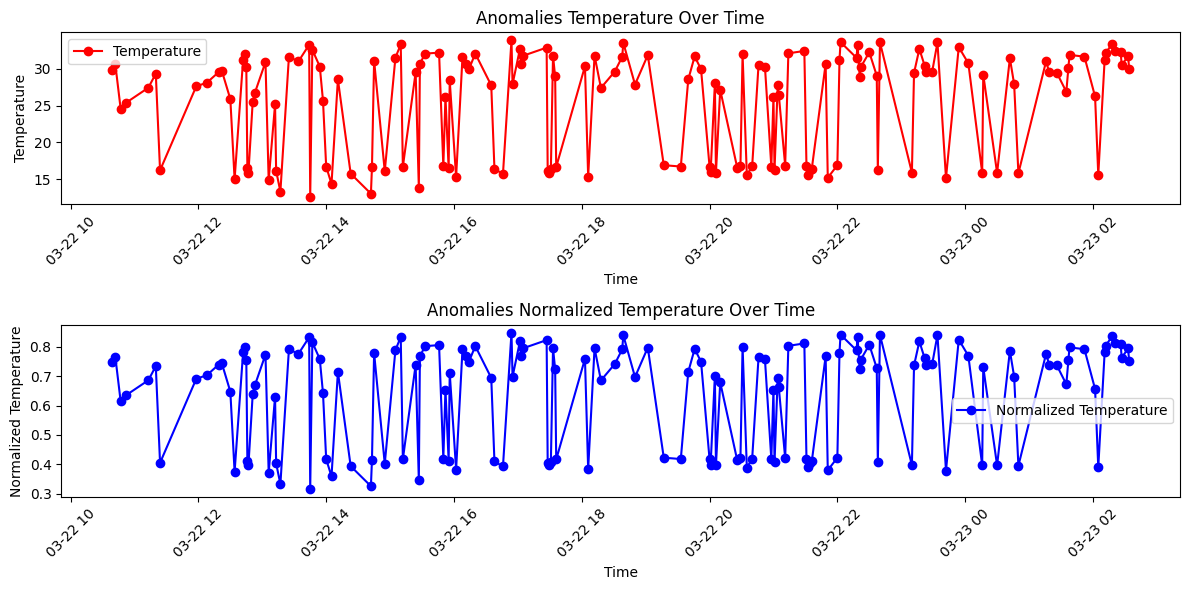

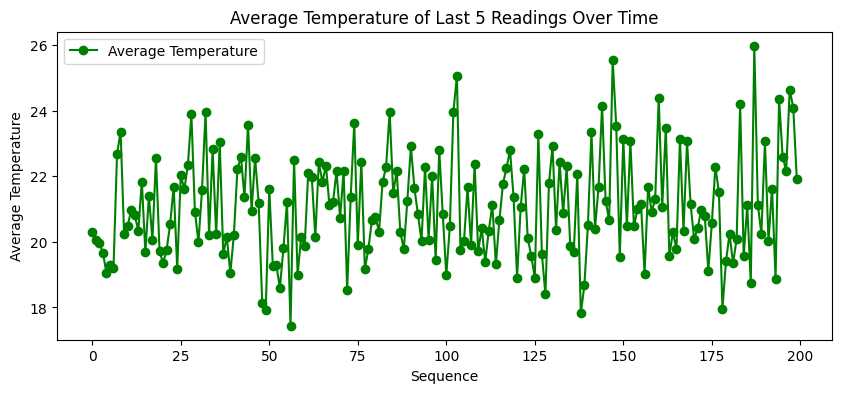

In [ ]:
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Initialize lists to store extracted data
timestamps = []
temperatures = []
normalized_temperatures = []
average_temperatures = []

# Regex patterns for matching lines
anomaly_pattern = re.compile(r"Anomaly detected at (\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}.\d{3}): Temperature=(\d+.\d+), Normalized Temp is (\d+.\d+)")
average_temp_pattern = re.compile(r"Average temperature of last 5 readings: (\d+.\d+)")

with open('sensor_output.txt', 'r') as file:
    for line in file:
        anomaly_match = anomaly_pattern.match(line)
        average_temp_match = average_temp_pattern.match(line)

        if anomaly_match:
            timestamp, temperature, normalized_temp = anomaly_match.groups()
            timestamps.append(datetime.strptime(timestamp, "%Y-%m-%dT%H:%M:%S.%f"))
            temperatures.append(float(temperature))
            normalized_temperatures.append(float(normalized_temp))

        elif average_temp_match:
            average_temperature = average_temp_match.groups()[0]
            average_temperatures.append(float(average_temperature))

# Visualization code
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(timestamps, temperatures, marker='o', linestyle='-', color='red', label='Temperature')
plt.title('Anomalies Temperature Over Time')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(timestamps, normalized_temperatures, marker='o', linestyle='-', color='blue', label='Normalized Temperature')
plt.title('Anomalies Normalized Temperature Over Time')
plt.xlabel('Time')
plt.ylabel('Normalized Temperature')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(average_temperatures, marker='o', linestyle='-', color='green', label='Average Temperature')
plt.title('Average Temperature of Last 5 Readings Over Time')
plt.xlabel('Sequence')
plt.ylabel('Average Temperature')
plt.legend()
plt.show()


## Parallel Pipeline workflow Traces

In [ ]:
## Multi mapping - with monitoring
!dispel4py timed_multi dispel4py.examples.graph_testing.parallel_pipeline -i 10 -n 15 --timing-dir /content/results/parallel_pipeline_multi_n15

Processing 10 iterations.
RUN ARGS: 
Namespace(target='timed_multi', module='dispel4py.examples.graph_testing.parallel_pipeline', attr=None, file=None, data=None, iter=10, provenance=None, simple=False, num=15, timing_dir='/content/results/parallel_pipeline_multi_n15', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summary_file=None, iteration_latency_summary_file=None, shape_file=None, concrete_shape_file=None, abstract_figure_file=None, concrete_figure_file=None, no_graph_figures=False, print_shape=False)
Timing monitor enabled for 4 PEs (run_id=20260424T180939002785Z).
Processes: {'TestProducer0': range(0, 1), 'TestOneInOneOut1': range(1, 5), 'TestOneInOneOut2': range(5, 9), 'TestOneInOneOut3': range(9, 13)}
TestProducer0 (rank 0): Average processing time: 6.198883056640625e-06
TestProducer0 (rank 0): Processed 10 iterations.
TestOneInOneOut1 (rank 4): Average processing time: 1.1205673217773438e-05
TestOneInOneOut1 (rank 1): Av

## Split and Merge Traces

In [ ]:
## Multi mapping - with monitoring
!dispel4py timed_multi dispel4py.examples.graph_testing.grouping_split_merge -i 5 -n 4 --timing-dir /content/results/split_merge_multi_n4

Processing 5 iterations.
RUN ARGS: 
Namespace(target='timed_multi', module='dispel4py.examples.graph_testing.grouping_split_merge', attr=None, file=None, data=None, iter=5, provenance=None, simple=False, num=4, timing_dir='/content/results/split_merge_multi_n4', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summary_file=None, iteration_latency_summary_file=None, shape_file=None, concrete_shape_file=None, abstract_figure_file=None, concrete_figure_file=None, no_graph_figures=False, print_shape=False)
Timing monitor enabled for 4 PEs (run_id=20260424T180941363623Z).
Processes: {'RandomWordProducer0': range(0, 1), 'RandomFilter1': range(1, 2), 'RandomFilter2': range(2, 3), 'WordCounter3': range(3, 4)}
RandomWordProducer0 (rank 0): Average processing time: 0.0004329681396484375
RandomFilter2 (rank 2): Average processing time: 0.00014324188232421874
RandomWordProducer0 (rank 0): Processed 5 iterations.
RandomFilter1 (rank 1): Average p

## Modifying word count


In [ ]:
%%writefile /content/my_workflow.py
from dispel4py.examples.graph_testing.testing_PEs import RandomWordProducer, WordCounter
from dispel4py.workflow_graph import WorkflowGraph

words = RandomWordProducer()
#words.numprocesses = 1
counter = WordCounter()
#counter.numprocesses = 3
graph = WorkflowGraph()
graph.connect(words, "output", counter, "input")

Writing /content/my_workflow.py


In [ ]:
!dispel4py timed_multi /content/my_workflow.py -i 1000 -n 20 --timing-dir /content/results/my_workflow

Processing 1000 iterations.
RUN ARGS: 
Namespace(target='timed_multi', module='/content/my_workflow.py', attr=None, file=None, data=None, iter=1000, provenance=None, simple=False, num=20, timing_dir='/content/results/my_workflow', timing_prefix='monitor', timing_run_id=None, summary_file=None, instance_summary_file=None, iteration_summary_file=None, iteration_latency_summary_file=None, shape_file=None, concrete_shape_file=None, abstract_figure_file=None, concrete_figure_file=None, no_graph_figures=False, print_shape=False)
Timing monitor enabled for 2 PEs (run_id=20260424T180943131031Z).
Processes: {'RandomWordProducer0': range(0, 1), 'WordCounter1': range(1, 20)}
RandomWordProducer0 (rank 0): Average processing time: 8.976054191589356e-05
WordCounter1 (rank 1): Average processing time: 0.0
WordCounter1 (rank 1): Processed 0 iterations.
WordCounter1 (rank 5): Average processing time: 2.424671964825324e-06
WordCounter1 (rank 5): Processed 159 iterations.
WordCounter1 (rank 2): Average p